In [0]:
#Propensity Scoring + SHAP Driver Analysis

In [0]:
 %pip install shap -q
 dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
#Config + imports

In [0]:
CATALOG = "cx"
SCHEMA_GOLD = "cx_gold"

import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    average_precision_score
)
import shap

In [0]:
 #Load and prepare target

In [0]:
c360 = spark.table(f"{CATALOG}.{SCHEMA_GOLD}.customer_360").toPandas()
segs = spark.table(f"{CATALOG}.{SCHEMA_GOLD}.customer_segments").toPandas()

df = c360.merge(segs, on="customer_id", how="left")
print(f"Total customers: {len(df):,}")
print(f"Customers with NPS responses: {df['latest_nps'].notna().sum():,}")

# Target: is this customer a Detractor?
df_model = df[df["latest_nps"].notna()].copy()
df_model["is_detractor"] = (df_model["latest_nps"] <= 6).astype(int)
print(f"\nTraining set (customers with NPS): {len(df_model):,}")
print(f"Detractor rate: {df_model['is_detractor'].mean():.1%}")

Total customers: 50,000
Customers with NPS responses: 14,958

Training set (customers with NPS): 14,958
Detractor rate: 37.2%


In [0]:
#Feature engineering
#Build feature matric

In [0]:
numeric_features = [
    "annual_recurring_revenue_usd",
    "tenure_years",
    "total_tickets",
    "tickets_per_year",
    "critical_tickets",
    "escalated_tickets",
    "avg_first_response_min",
    "avg_resolution_hours",
    "avg_post_ticket_csat",
    "avg_monthly_test_volume",
    "avg_uptime_pct",
    "avg_monthly_errors",
    "active_instruments",
    "software_versions_used",
    "engagement_score",
    "has_recent_critical",
    "employee_count",
]

categorical_features = ["service_tier", "customer_type", "region"]

X_num = df_model[numeric_features].copy()
X_cat = pd.get_dummies(df_model[categorical_features], drop_first=True)
X = pd.concat([X_num, X_cat], axis=1)
y = df_model["is_detractor"]

print(f"Feature matrix: {X.shape}")
print(f"Class balance: {y.value_counts(normalize=True).round(3).to_dict()}")


Feature matrix: (14958, 25)
Class balance: {0: 0.628, 1: 0.372}


In [0]:
#Train/test split

In [0]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  Test: {len(X_test):,}")

Train: 11,218  Test: 3,740


In [0]:
#Train with MLflow tracking

In [0]:
current_user = spark.sql("SELECT current_user()").collect()[0][0]
mlflow.set_experiment(f"/Users/{current_user}/cx_propensity_model")

with mlflow.start_run(run_name="detractor_propensity_v1") as run:
    params = {
        "learning_rate": 0.1,
        "max_iter": 200,
        "max_depth": 6,
        "min_samples_leaf": 30,
        "random_state": 42,
    }
    mlflow.log_params(params)

    model = HistGradientBoostingClassifier(**params)
    model.fit(X_train, y_train)

    train_proba = model.predict_proba(X_train)[:, 1]
    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= 0.5).astype(int)

    train_auc = roc_auc_score(y_train, train_proba)
    test_auc = roc_auc_score(y_test, test_proba)
    test_ap = average_precision_score(y_test, test_proba)

    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("test_auc", test_auc)
    mlflow.log_metric("test_avg_precision", test_ap)

    print(f"Train AUC: {train_auc:.3f}")
    print(f"Test AUC:  {test_auc:.3f}")
    print(f"Test AP:   {test_ap:.3f}")
    print(f"\nClassification report (threshold=0.5):")
    print(classification_report(y_test, test_pred, digits=3))

    mlflow.sklearn.log_model(model, "model")
    run_id = run.info.run_id
    print(f"\n✅ MLflow run ID: {run_id}")



2026/05/22 19:47:36 INFO mlflow.tracking.fluent: Experiment with name '/Users/aayushamrute02@gmail.com/cx_propensity_model' does not exist. Creating a new experiment.
2026/05/22 19:47:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train AUC: 0.668
Test AUC:  0.510
Test AP:   0.391

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.628     1.000     0.771      2347
           1      1.000     0.001     0.001      1393

    accuracy                          0.628      3740
   macro avg      0.814     0.500     0.386      3740
weighted avg      0.766     0.628     0.485      3740



🔗 View Logged Model at: https://dbc-a829c593-b92e.cloud.databricks.com/ml/experiments/4173957732401825/models/m-66bb2191ed2448ed8426f69d5e748f26?o=7474644127873251
2026/05/22 19:47:42 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.



✅ MLflow run ID: d85f6bbc47e14828bfe5da7ea7b71e9e


In [0]:
#SHAP — explainable driver analysis

#SHAP values tell you, **per customer**, which features pushed their detractor probability up or down. This is the "explainable, business-relevant methods" piece from the JD.

In [0]:
#Compute SHAP values

In [0]:
X_sample = X_test.sample(min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 25)


In [0]:
#Global feature importance — mean absolute SHAP

Top 10 detractor drivers:
                     feature  mean_abs_shap
            tickets_per_year       0.026614
     avg_monthly_test_volume       0.025629
annual_recurring_revenue_usd       0.022438
              avg_uptime_pct       0.022299
          active_instruments       0.022016
        avg_post_ticket_csat       0.018376
          avg_monthly_errors       0.017901
        avg_resolution_hours       0.016756
                tenure_years       0.012248
      avg_first_response_min       0.010882


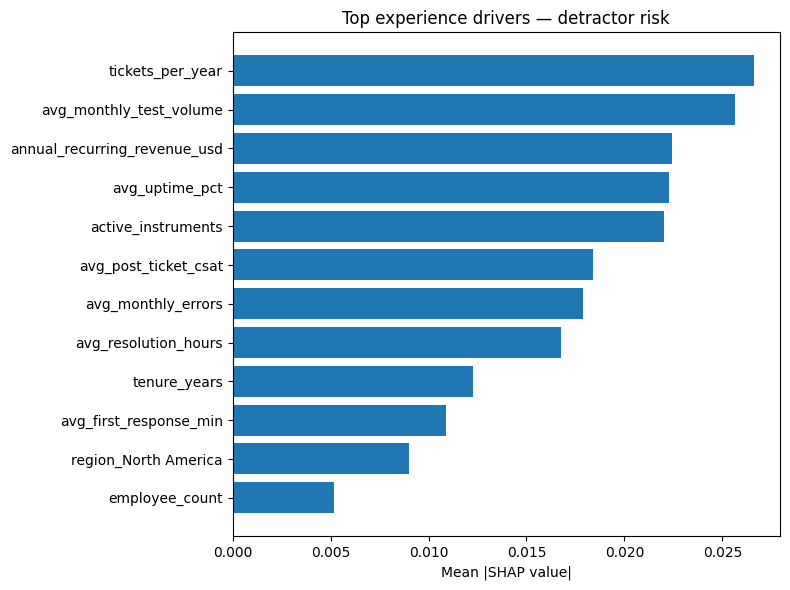

In [0]:
shap_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print("Top 10 detractor drivers:")
print(shap_importance.head(10).to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 6))
top = shap_importance.head(12)
plt.barh(top["feature"][::-1], top["mean_abs_shap"][::-1])
plt.xlabel("Mean |SHAP value|")
plt.title("Top experience drivers — detractor risk")
plt.tight_layout()
plt.show()

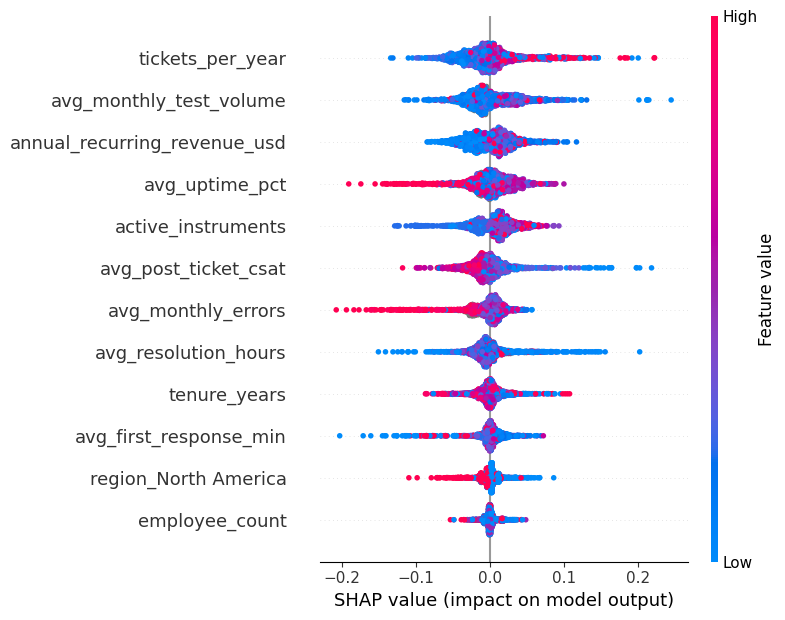

In [0]:
#SHAP summary plot — direction of effect
#Red = high feature value, blue = low. Shows whether high or low values push toward detractor.

shap.summary_plot(shap_values, X_sample, max_display=12, show=True)

In [0]:
# Score ALL customers (not just those with NPS)
#The trained model predicts detractor risk even for customers who haven't responded
#to a survey. This is the real business value — anticipating risk before they tell you.

In [0]:
#Score full customer base
X_all_num = df[numeric_features].copy()
X_all_cat = pd.get_dummies(df[categorical_features], drop_first=True)

# Align columns with training matrix
X_all = pd.concat([X_all_num, X_all_cat], axis=1)
X_all = X_all.reindex(columns=X.columns, fill_value=0)

df["detractor_risk_score"] = model.predict_proba(X_all)[:, 1]
df["risk_band"] = pd.cut(
    df["detractor_risk_score"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=["Low", "Medium", "High", "Critical"],
)

print("Risk band distribution:")
print(df["risk_band"].value_counts().sort_index())


Risk band distribution:
risk_band
Low             2
Medium      49984
High           14
Critical        0
Name: count, dtype: int64


In [0]:
#Save to Gold tables
scores_out = df[["customer_id", "detractor_risk_score", "risk_band"]].copy()
scores_out["detractor_risk_score"] = scores_out["detractor_risk_score"].round(4)
scores_out["risk_band"] = scores_out["risk_band"].astype(str)

spark.createDataFrame(scores_out).write.mode("overwrite").format("delta").saveAsTable(
    f"{CATALOG}.{SCHEMA_GOLD}.customer_propensity"
)
print(f"✅ Saved {len(scores_out):,} propensity scores to {CATALOG}.{SCHEMA_GOLD}.customer_propensity")

shap_importance_out = shap_importance.copy()
shap_importance_out["mean_abs_shap"] = shap_importance_out["mean_abs_shap"].round(4)
spark.createDataFrame(shap_importance_out).write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable(
    f"{CATALOG}.{SCHEMA_GOLD}.experience_drivers"
)
print(f"✅ Saved driver importance to {CATALOG}.{SCHEMA_GOLD}.experience_drivers")


✅ Saved 50,000 propensity scores to cx.cx_gold.customer_propensity
✅ Saved driver importance to cx.cx_gold.experience_drivers


In [0]:

%sql
--Top 10 highest-risk customers
SELECT
  c.customer_id,
  c.customer_type,
  c.service_tier,
  ROUND(c.annual_recurring_revenue_usd, 0) AS arr,
  s.segment_name,
  ROUND(p.detractor_risk_score, 3) AS risk_score,
  p.risk_band
FROM cx.cx_gold.customer_360 c
JOIN cx.cx_gold.customer_propensity p USING (customer_id)
JOIN cx.cx_gold.customer_segments s USING (customer_id)
ORDER BY c.annual_recurring_revenue_usd * p.detractor_risk_score DESC
LIMIT 10


customer_id,customer_type,service_tier,arr,segment_name,risk_score,risk_band
CUST_023774,Hospital,Gold,5489382.0,At-Risk High-Touch,0.36,Medium
CUST_038181,Research,Silver,2883614.0,Dormant / Disengaged,0.37,Medium
CUST_016567,Clinical Lab,Bronze,2145098.0,Silent Majority,0.445,Medium
CUST_012503,Hospital,Gold,1941960.0,Silent Majority,0.423,Medium
CUST_028506,Hospital,Bronze,2046727.0,Silent Majority,0.381,Medium
CUST_039365,Hospital,Bronze,2202970.0,Silent Majority,0.346,Medium
CUST_033540,Clinical Lab,Bronze,1947359.0,Silent Majority,0.377,Medium
CUST_040781,Clinical Lab,Gold,2028209.0,Silent Majority,0.341,Medium
CUST_038726,Specialty Clinic,Bronze,1727647.0,Silent Majority,0.381,Medium
CUST_022841,Specialty Clinic,Bronze,1641606.0,Silent Majority,0.375,Medium


In [0]:
%sql
--Risk band × segment crosstab
 SELECT
   s.segment_name,
   p.risk_band,
   COUNT(*) AS customers,
   ROUND(AVG(c.annual_recurring_revenue_usd), 0) AS avg_arr
 FROM cx.cx_gold.customer_360 c
 JOIN cx.cx_gold.customer_propensity p USING (customer_id)
 JOIN cx.cx_gold.customer_segments s USING (customer_id)
 GROUP BY s.segment_name, p.risk_band
 ORDER BY s.segment_name, p.risk_band


segment_name,risk_band,customers,avg_arr
At-Risk High-Touch,High,3,119485.0
At-Risk High-Touch,Medium,8610,66107.0
Dormant / Disengaged,Medium,9544,64527.0
Silent Majority,High,6,57736.0
Silent Majority,Low,2,145424.0
Silent Majority,Medium,23102,67038.0
Strategic Champions,High,5,57710.0
Strategic Champions,Medium,8728,65691.0


In [0]:
import pandas as pd

# Load current propensity scores
prop = spark.table("cx.cx_gold.customer_propensity").toPandas()

# Re-band by quartile (within the actual score distribution)
prop["risk_band"] = pd.qcut(
    prop["detractor_risk_score"],
    q=4,
    labels=["Low", "Medium", "High", "Critical"]
).astype(str)

# Show new distribution
print("New risk band distribution:")
print(prop["risk_band"].value_counts().sort_index())

# Save back
spark.createDataFrame(prop).write.mode("overwrite").option("overwriteSchema", "true").format("delta").saveAsTable(
    "cx.cx_gold.customer_propensity"
)
print("\n✅ Re-banded and saved")

New risk band distribution:
risk_band
Critical    12473
High        12460
Low         12541
Medium      12526
Name: count, dtype: int64

✅ Re-banded and saved


In [0]:
%sql
SELECT risk_band, COUNT(*) AS customers
FROM cx.cx_gold.customer_propensity
GROUP BY risk_band
ORDER BY risk_band;

risk_band,customers
Critical,12473
High,12460
Low,12541
Medium,12526


In [0]:
%sql
SELECT s.segment_name, p.risk_band, COUNT(*) AS customers
FROM cx.cx_gold.customer_segments s
JOIN cx.cx_gold.customer_propensity p USING (customer_id)
GROUP BY s.segment_name, p.risk_band
ORDER BY s.segment_name, p.risk_band;

segment_name,risk_band,customers
At-Risk High-Touch,Critical,3068
At-Risk High-Touch,High,2083
At-Risk High-Touch,Low,1635
At-Risk High-Touch,Medium,1827
Dormant / Disengaged,Critical,1187
Dormant / Disengaged,High,2170
Dormant / Disengaged,Low,3215
Dormant / Disengaged,Medium,2972
Silent Majority,Critical,5809
Silent Majority,High,5849


In [0]:
%sql
SELECT s.segment_name,
       ROUND(AVG(p.detractor_risk_score), 3) AS avg_risk_score,
       MIN(p.detractor_risk_score) AS min_risk,
       MAX(p.detractor_risk_score) AS max_risk
FROM cx.cx_gold.customer_segments s
JOIN cx.cx_gold.customer_propensity p USING (customer_id)
GROUP BY s.segment_name
ORDER BY avg_risk_score DESC;

segment_name,avg_risk_score,min_risk,max_risk
At-Risk High-Touch,0.379,0.2517,0.5193
Strategic Champions,0.374,0.2585,0.5267
Silent Majority,0.372,0.2335,0.5249
Dormant / Disengaged,0.365,0.2746,0.492
